# Volcano plots
**Volcano plots** are commonly used in genomics, proteomics, and statistical association studies to visualise the relationship between effect magnitude and statistical significance.

Each point typically represents a single feature or comparison (e.g. a gene, protein, or SNP), with:
- the **effect size** (e.g. log fold-change, regression coefficient) on the x-axis, and  
- the **–log₁₀(p-value)** on the y-axis, so that more significant results appear higher on the plot.

This layout enables rapid identification of results that are both statistically significant and large in magnitude. Volcano plots are particularly useful for prioritising features in high-throughput analyses and communicating key results.
The examples below demonstrate how to generate volcano plots using the `plot_volcano` function, which supports annotation, axis control, and label adjustment for overlapping text.

In [1]:
# %%%%%%%% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plot_misc import volcano
import plot_misc.example_data.examples as examples

In [2]:
# load data
data = examples.load_volcano_data()
data.head()

,phenotype,point,se,pvalue,multiple_testing_threshold,pvalue_log10
exposure,,,,,,
13472_35_3_HDHD2,P-wave force,-4931.106973,1899.108629,0.009417,0.000005,2.026094
10772_21_3_CSGALNACT2,P-wave force,-276.968492,82.984159,0.000845,0.000005,3.073127
13242_134_3_SHANK3,P-wave force,-235.351339,88.982756,0.008171,0.000005,2.087710
5012_67_1_AK1,P-wave force,NaN,NaN,NaN,0.000005,NaN
9335_28_3_PSG9,P-wave force,-402.545894,195.034845,0.039021,0.000005,1.408706


In [3]:
# constants
CMTOINCH = 1/2.54
# The y, x axes labels,title, point size, text size,
# ytick size, x ticks size
ANNOT_SIZE = [6.0, 6.0, 10.0, 15.0, 3.4, 14.0, 14.0]
# using standard colours
COLOURS = ('orangered','dimgrey','lightcoral')
# setting size (in cm)
FIG_SIZE = [float(r) * CMTOINCH for r in  [4.5,5.5]]
# setting threshold
SIGNIFICANCE = data['multiple_testing_threshold'].unique()[0]
YLIM = [0, 22] # adding some space to the top
XLIM = [-800,800]
# Title
TITLE = str(data['phenotype'].unique()[0])
TL = 3

## Plotting a volcano


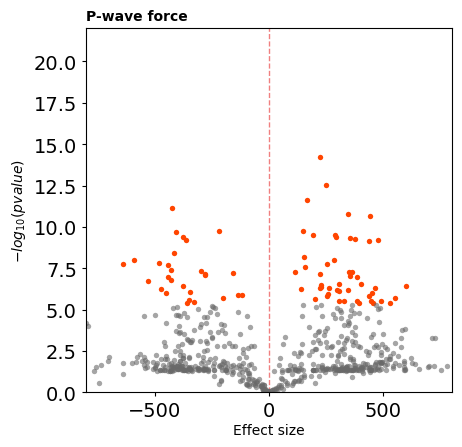

In [4]:
# making subplots
fig, ax = plt.subplots(1, 1, figsize=(12 * CMTOINCH, 12 * CMTOINCH))
# make sure to set the xlim before plotting 
ax.set_xlim(XLIM)
# title
_, _ = volcano.plot_volcano(data,y_column='pvalue_log10',
                                x_column='point',
                                ylim = YLIM,
                                col=COLOURS,
                                msize=ANNOT_SIZE[3],
                                alpha=SIGNIFICANCE,
                                xlab='Effect size', ylab=r'$-log_{10}(pvalue)$',
                                ax=ax,
                                )
# add title
ax.set_title(TITLE, loc='left', y=1.00, fontsize=ANNOT_SIZE[2],
             fontdict={'fontweight': 'bold'})
ax.xaxis.labelpad = 2
ax.tick_params(axis='y', labelsize=ANNOT_SIZE[5], length=TL)
ax.tick_params(axis='x', labelsize=ANNOT_SIZE[6], length=TL)

## Annotations
Next we will annotate some of the significant results. For this we will supply a list of `data.indices` to plot labels for. 

In [5]:
data['label'] = None
data.loc['9316_67_3_WFDC1',  'label'] = 'WFDC1'
index = ['9316_67_3_WFDC1']
data.iloc[10:16,]

,phenotype,point,se,pvalue,multiple_testing_threshold,pvalue_log10,label
exposure,,,,,,,
6077_63_3_CECR1,P-wave force,101.620825,48.731654,3.704076e-02,0.000005,1.431320,None
9282_12_3_CRISP2,P-wave force,-220.303910,34.565643,1.847700e-10,0.000005,9.733369,None
3212_30_3_ASAH2,P-wave force,140.370108,28.140184,6.093052e-07,0.000005,6.215165,None
13954_9_3_GNPNAT1,P-wave force,NaN,NaN,NaN,0.000005,NaN,None
6576_1_3_ART4,P-wave force,221.879569,67.828538,1.070985e-03,0.000005,2.970216,None
9316_67_3_WFDC1,P-wave force,442.297259,66.154470,2.296252e-11,0.000005,10.638980,WFDC1


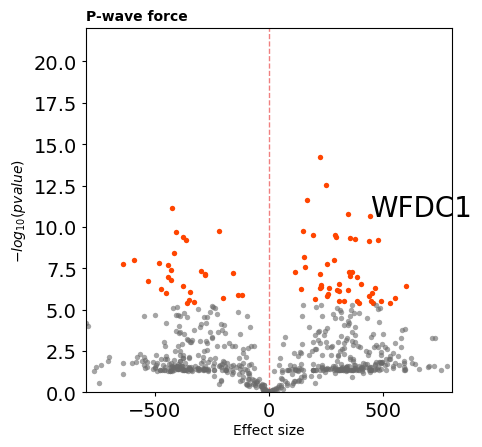

In [6]:
# making subplots
fig, ax = plt.subplots(1, 1, figsize=(12 * CMTOINCH, 12 * CMTOINCH))
# make sure to set the xlim before plotting 
ax.set_xlim(XLIM)
# title
_, _ = volcano.plot_volcano(data,y_column='pvalue_log10',
                                x_column='point',
                                ylim = YLIM,
                                col=COLOURS,
                                msize=ANNOT_SIZE[3],
                                alpha=SIGNIFICANCE,
                                xlab='Effect size', ylab=r'$-log_{10}(pvalue)$',
                                ax=ax,
                                # THIS IS NEW!
                                point_label='label',
                                index_label=index,
                                lsize=20,
                                )
# add title
ax.set_title(TITLE, loc='left', y=1.00, fontsize=ANNOT_SIZE[2],
             fontdict={'fontweight': 'bold'})
ax.xaxis.labelpad = 2
ax.tick_params(axis='y', labelsize=ANNOT_SIZE[5], length=TL)
ax.tick_params(axis='x', labelsize=ANNOT_SIZE[6], length=TL)

## Font type
The annotation font type can also be adjusted using the `font_label` parameter. 

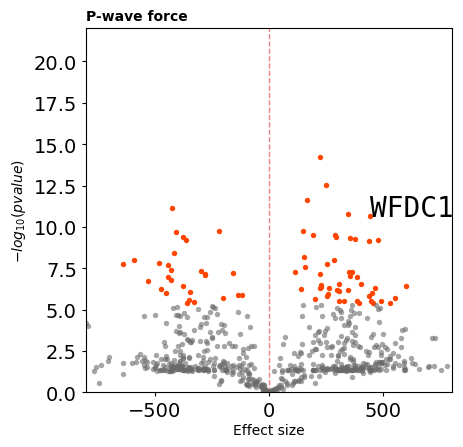

In [7]:
# Different fot for the dot annotation
fig, ax = plt.subplots(1, 1, figsize=(12 * CMTOINCH, 12 * CMTOINCH))
# make sure to set the xlim before plotting 
ax.set_xlim(XLIM)
# title
_, _ = volcano.plot_volcano(data,y_column='pvalue_log10',
                                x_column='point',
                                ylim = YLIM,
                                col=COLOURS,
                                msize=ANNOT_SIZE[3],
                                alpha=SIGNIFICANCE,
                                xlab='Effect size', ylab=r'$-log_{10}(pvalue)$',
                                ax=ax,
                                point_label='label',
                                index_label=index,
                                # THIS IS NEW!
                                font_label="DejaVu Sans Mono",
                                lsize=20,
                                )
# add title
ax.set_title(TITLE, loc='left', y=1.00, fontsize=ANNOT_SIZE[2],
             fontdict={'fontweight': 'bold'})
ax.xaxis.labelpad = 2
ax.tick_params(axis='y', labelsize=ANNOT_SIZE[5], length=TL)
ax.tick_params(axis='x', labelsize=ANNOT_SIZE[6], length=TL)

In [8]:
help(volcano)

Help on module plot_misc.volcano in plot_misc:

NAME
    plot_misc.volcano - Volcano plots for visualising effect size and statistical significance.

DESCRIPTION
    This module provides a template to create volcano plots for highlighting
    results based on both the magnitude of effect and their statistical
    significance. Typically, the x-axis shows an effect estimate and the y-axis
    the negative log-transformed p-value. Dots can be coloured to distinguish
    significant from non-significant results, and selected points may be annotated
    with text labels.
    
    Functions
    ---------
    plot_volcano(data, y_column, x_column, point_label=None,  ...)
        Draws a volcano plot, optionally adding a vertical reference line and
        labels for significant points.
    
    Notes
    -----
    These implementations are designed to work directly with matplotlib `Axes`
    objects, and optionally allow de-overlapping of text using `adjustText`.
    Appearance can be modifi